# Analisis Data: Philippine Cities Air Quality Index Data 2026
Proyek Analisis Data Eksploratif (EDA) untuk mata kuliah **Probabilitas dan Statistika (StatProb)** oleh **Kelompok 11**.

## 1. Judul dan identitas kelompok

#### Judul
Analisis Pola Kualitas Udara dan Konsentrasi Polutan di Kota-Kota Filipina Tahun 2026

#### Anggota Kelompok 11

| No | Nama | NRP |
| :---: | :--- | :---: |
| 1 | **Ahmad Sofyan Badawi** | `5027261065` |
| 2 | **Arif Budianto** | `5027261029` |
| 3 | **Nandana Reswara** | `5027261102` |

#### Topik Yang Dipilih: SmartCity

## 2. Latar belakang dan pertanyaan

#### Kenapa Kami Memilih Dataset ini
Polusi udara merupakan salah satu tantangan utama di wilayah perkotaan yang berdampak langsung pada kesehatan masyarakat. Dataset *Philippine Cities Air Quality Index Data 2026* ini sangat menarik untuk dieksplorasi karena menyediakan rekaman konsentrasi berbagai polutan secara mendetail dan berkala (interval jam). Melalui data ini, kita dapat membedah kondisi udara di berbagai kota secara nyata, melihat polutan apa yang paling mendominasi, serta memahami sebaran tingkat bahayanya sebagai langkah awal membangun pemodelan sistem *Smart City*.

#### Pertanyaan Analisis:
1. Bagaimana perbandingan pemusatan dan penyebaran kadar polutan utama (CO, PM2.5, dan O3)?
2. Apakah terdapat lonjakan polusi ekstrem atau anomali pada pengukuran partikel kasar (PM10)?
3. Bagaimana pola hubungan antara konsentrasi debu halus (PM2.5) dan debu kasar (PM10) di udara?
4. Apakah distribusi letak sensor pengukuran didominasi oleh kota-kota tertentu?

## 3. Memuat Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/dataset.csv")
print(df.shape)   # (jumlah baris, jumlah kolom)
df.head()

(85496, 11)


,datetime,main.aqi,components.co,components.no,components.no2,components.o3,components.so2,components.pm2_5,components.pm10,components.nh3,city_name
0,2026-09-01 00:00:00+08:00,2.0,139.32,0.0,0.26,64.05,0.21,11.45,21.74,0.06,Alaminos
1,2026-09-01 00:00:02+08:00,2.0,218.42,0.0,0.22,85.81,0.23,13.37,30.16,0.55,Angeles City
2,2026-09-01 00:00:04+08:00,2.0,233.01,0.0,1.11,81.92,0.60,9.25,16.91,0.72,Antipolo
3,2026-09-01 00:00:07+08:00,1.0,168.57,0.0,2.79,32.26,0.64,4.53,6.12,1.32,Bacolod
4,2026-09-01 00:00:09+08:00,2.0,252.49,0.0,0.25,92.17,0.21,9.30,21.69,0.78,Bacoor


### Penjelasan Data
Setiap baris pada dataset ini mewakili rekaman observasi satu kali pengukuran indeks kualitas udara beserta kadar polutannya (CO, O3, PM2.5, PM10, dll.) dari sebuah sensor di satu kota tertentu (Philippina) pada satu waktu (`datetime`) yang spesifik.

## 4. Deskripsi Data dan Kamus Data

### Tentang Dataset
Dataset yang digunakan memuat data indeks kualitas udara (*Air Quality Index* - AQI) dan berbagai konsentrasi polutan di berbagai kota di Filipina untuk tahun 2026.

Data ini publish oleh [BwandoWando](BwandoWando), menurut keterangannya data ini diambil dengan scrapping website https://openweathermap.org menggunakan python dengan rentang waktu interval 1 jam sekali (1-hour intervals) untuk 138 kota besar di Filipina.

Lalu data ini masih diupdate sampai sekarang, yang artinya dataset ini diperbarui secara berkala oleh si Author 

**Sumber Dataset**: [Kaggle - Philippine Cities Air Quality Index Data 2026](https://www.kaggle.com/datasets/bwandowando/philippine-cities-air-quality-index-data-2026)

**Lisensi**: [CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/)

**Jumlah Baris**: 85496

**Jumlah Kolom**: 11



### Kamus Data / Deskripsi Variabel

| Kolom | Arti | Jenis Variabel | Skala Pengukuran | Satuan | Contoh Nilai |
| :--- | :--- | :--- | :--- | :---: | :--- |
| `datetime` | Waktu dan tanggal pengambilan data kualitas udara | Kuantitatif | Interval | - |  2026-09-01 00:00:07+08:00 |
| `main.aqi` | Indeks Kualitas Udara (Air Quality Index) | Kuantitatif | Ordinal | - | 3 |
| `components.co` | Konsentrasi gas Karbon Monoksida di udara | Kuantitatif Kontinu | Rasio | µg/m³ | 139.32, 218.42 |
| `components.no` | Konsentrasi Nitrogen Monoksida di udara | Kuantitatif Kontinu | Rasion | µg/m³ | 0.15 |
| `components.no2` | Konsentrasi Nitrogen Dioksida di udara | Kuantitatif Kontinu | Rasion | µg/m³ | 0.22 |
| `components.o3` | Konsentrasi gas Ozon di permukaan tanah | Kuantitatif Kontinu | Rasio | µg/m³ | 64.05 |
| `components.so2` | Konsentrasi Sulfur Dioksida di udara | Kuantitatif Kontinu | Rasio | µg/m³ | 0.21 |
| `components.pm2_5` | Konsentrasi partikel debu halus (ukuran < 2,5 mikrometer) | Kuantitatif Kontinu | Rasio | µg/m³ | 9.25, 11.45 |
| `components.pm10` | Konsentrasi partikel debu kasar (ukuran < 10 mikrometer) | Kuantitatif Kontinu | Rasio | µg/m³ | 16.91, 30.16 |
| `components.nh3` | Konsentrasi Amonia di udara | Kuantitatif Kontinu | Rasio | µg/m³ | 0.06 |
| `city_name` | Nama kota lokasi sensor pengukuran kualitas udara berada | Kualitatif | Nominal | - | Alaminos, Bacolod |

## 5. Pemeriksaan kualitas data

In [2]:
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.DataFrame'>
RangeIndex: 85496 entries, 0 to 85495
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          85496 non-null  str    
 1   main.aqi          85496 non-null  float64
 2   components.co     85496 non-null  float64
 3   components.no     85496 non-null  float64
 4   components.no2    85496 non-null  float64
 5   components.o3     85496 non-null  float64
 6   components.so2    85496 non-null  float64
 7   components.pm2_5  85496 non-null  float64
 8   components.pm10   85496 non-null  float64
 9   components.nh3    85496 non-null  float64
 10  city_name         85496 non-null  str    
dtypes: float64(9), str(2)
memory usage: 7.2 MB


np.int64(0)

### Interpretasi Pemeriksaan Kualitas Data:
Berdasarkan hasil pengecekan di atas, dataset ini sangat bersih. Terdapat total 85.496 baris data dan 11 kolom, tanpa ada satu pun nilai yang kosong (`NaN` atau null) dan tidak ditemukan baris yang terduplikasi. Oleh karena itu, kita tidak perlu melakukan tahapan *data cleaning* seperti imputasi atau *drop* baris, dan dataset ini bisa langsung digunakan untuk analisis lanjutan.

## 6. Statistik Deskriptif Variabel Numerik

In [3]:
kolomKolom = df[["components.co", "components.pm2_5", "components.o3"]]

def membuatTabelRingkasan(koloms):
    hasilTabel = {}
    for namaKolom in koloms.columns:
            kolom = df[namaKolom]
            Q1 = kolom.quantile(0.25)
            Q3 = kolom.quantile(0.75)
            hasilTabel[namaKolom] = {
                "Rata-rata": kolom.mean(), 
                "Median": kolom.median(), 
                "Modus": kolom.mode()[0], 
                "Mininum": kolom.min(), 
                "Maximum": kolom.max(), 
                "Jangkauan": kolom.max() - kolom.min(), 
                "Varians": kolom.var(), 
                "Simpangan Baku": kolom.std(),  
                "Q1": Q1,  
                "Q3": Q3,  
                "IQR": Q3 - Q1,  
                }
    
    return pd.DataFrame(data=hasilTabel)

print(membuatTabelRingkasan(kolomKolom), "\n\n")

                components.co  components.pm2_5  components.o3
Rata-rata          208.074861          7.156114      53.813567
Median             189.190000          3.580000      51.795000
Modus              181.630000          1.590000      50.230000
Mininum             72.350000          0.500000       0.390000
Maximum            956.280000        154.800000     287.590000
Jangkauan          883.930000        154.300000     287.200000
Varians           7452.723145        103.285893     478.720153
Simpangan Baku      86.329156         10.162967      21.879674
Q1                 146.470000          2.100000      42.550000
Q3                 249.920000          7.270000      63.290000
IQR                103.450000          5.170000      20.740000 




### Interpretasi dan Analisis Sebaran Data

#### 1. Komponen CO (components.co) - Satuan: µg/m³
* **Pemusatan**: 

    Rata-rata kadar CO selama masa pengamatan adalah 208,074861 µg/m³, dengan median sebesar 189,19 µg/m³ dan kondisi kadar yang sering muncul (modus) adalah 181,63 µg/m³.

* **Penyebaran**: 

    Kadar CO terendah (minimum) yang tercatat adalah 72,35 µg/m³ dan tertinggi (maksimum) adalah 956,28 µg/m³, sehingga jarak penyebaran total (jangkauan) adalah 883,93 µg/m³. Data ini memiliki varians 7452,723145 (µg/m³)² dan simpangan baku sebesar 86,329156 µg/m³.
  
* **Letak**:
    
    Seperempat data pengamatan (25%) memiliki kadar CO di bawah 146,47 µg/m³ (Q1), tiga perempat data (75%) berada di bawah 249,92 µg/m³ (Q3), dan separuh data yang berada di tengah menyebar dalam rentang IQR sebesar 103,45 µg/m³.
  
* **Bentuk Sebaran**: 

    Karena nilai rata-rata (208,074861 µg/m³) lebih besar dari median (189,19 µg/m³), sehingga sebaran datanya akan miring ke kanan (Positive Skewness).

#### 2. Komponen PM2.5 (components.pm2_5) — Satuan: µg/m³
* **Pemusatan**: 

    Rata-rata konsentrasi PM2.5 adalah sebesar 7,156114 µg/m³, dengan nilai tengah (median) sebesar 3,58 µg/m³, dan nilai modus sebesar 1,59 µg/m³.
  
* **Penyebaran**: 

    Konsentrasi PM2.5 berkisar antara 0,50 µg/m³ hingga 154,8 µg/m³, menghasilkan jangkauan sebesar 154,30 µg/m³. Nilai varians tercatat sebesar 103,285893 (µg/m³)² dengan simpangan baku sebesar 10,162967 µg/m³.
  
* **Letak**: 

    Nilai batas kuartil bawah (Q1) adalah 2,1 µg/m³ dan kuartil atas (Q3) adalah 7,27 µg/m³, sehingga jarak antara 50% data di pusat (IQR) adalah sebesar 5,17 µg/m³.
  
* **Bentuk Sebaran**: 
    
    Karena nilai rata-rata (7,156114 µg/m³) hampir lebih dari 2 kali lipat dari median (3,58 µg/m³), sehingga sebaran datanya akan miring ke kanan (Positive Skewness).

#### 3. Komponen O3 (components.o3) — Satuan: µg/m³
* **Pemusatan**: 

    Rata-rata polutan O3 adalah sebesar 53,813567 µg/m³, dengan nilai median 51,795 µg/m³, dan modus sebesar 50,23 µg/m³.
  
* **Penyebaran**: 

    Kadar O3 bergerak dari titik terendah 0,39 µg/m³ sampai titik tertinggi 287,59 µg/m³, dengan nilai jangkauan sebesar 287,2 µg/m³. Sebaran data di sekitar rata-rata ditunjukkan oleh nilai varians sebesar 478,720153 (µg/m³)² dan simpangan baku sebesar 21,879674 µg/m³.
  
* **Letak**: 

    Nilai batas kuartil bawah (Q1) adalah 42,55 µg/m³ dan kuartil atas (Q3) adalah 63,29 µg/m³, sehingga jarak antara 50% data di pusat (IQR) adalah sebesar 20,74 µg/m³.
  
* **Bentuk Sebaran**: 

    Karena nilai rata-rata (53,813567 µg/m³) lebih besar dari median (51,795 µg/m³), sehingga sebaran datanya akan miring ke kanan.

### Perhitungan Manual

In [4]:
import math
# Perhitungan Manual
kolomCO = df["components.co"]
kolomCOHead10 = kolomCO.head(10)
# Cari rata-ratanya
rataRata = kolomCOHead10.mean()
print("===== Hitung Manual Menggunakan Rumus =====\n")
print("Mean dari 10 baris teratas: ", kolomCOHead10.mean())

sumOfDeviasi = 0
for i in range (len(kolomCOHead10)):
    deviasi = (kolomCOHead10[i] - rataRata) ** 2
    print(f"deviasi row {i}: ", deviasi)
    sumOfDeviasi += deviasi

print("Jumlah deviasi: ", sumOfDeviasi)
print("Varians (manual): ", sumOfDeviasi / 9)

print("Varians: ", kolomCOHead10.var())

print("Simpangan baku (manual): ", math.sqrt(sumOfDeviasi / 9))
print("Simpangan baku: ", kolomCOHead10.std())

===== Hitung Manual Menggunakan Rumus =====

Mean dari 10 baris teratas:  180.54299999999998
deviasi row 0:  1699.3357289999988
deviasi row 1:  1434.6671290000006
deviasi row 2:  2752.7860890000015
deviasi row 3:  143.35272899999964
deviasi row 4:  5176.370809000005
deviasi row 5:  7576.483848999997
deviasi row 6:  29.77884900000024
deviasi row 7:  8383.782968999994
deviasi row 8:  3084.3583690000037
deviasi row 9:  72.53928900000041
Jumlah deviasi:  30353.455810000003
Varians (manual):  3372.6062011111117
Varians:  3372.6062011111117
Simpangan baku (manual):  58.074143998091884
Simpangan baku:  58.074143998091884


## 7. Ringkasan Variabel Kategorik

In [5]:
# Menampilkan frekuensi kemunculan tiap kategori
print("5 Kota Teratas (Frekuensi):")
print(df['city_name'].value_counts().head(5))

# Menampilkan persentase kemuncula
print("\n5 Kota Teratas (Persentase):")
print(df['city_name'].value_counts(normalize=True).head(5) * 100)

5 Kota Teratas (Frekuensi):
city_name
Alaminos        623
Angeles City    623
Bacolod         623
Bago City       623
Baguio          623
Name: count, dtype: int64

5 Kota Teratas (Persentase):
city_name
Alaminos        0.728689
Angeles City    0.728689
Bacolod         0.728689
Bago City       0.728689
Baguio          0.728689
Name: proportion, dtype: float64


### Interpretasi Variabel Kategorik (city_name):
Berdasarkan hasil analisis, distribusi letak sensor pengukuran kualitas udara sangatlah merata. Menariknya, terdapat 99 kota (dari total keseluruhan 139 kota) yang memegang nilai kemunculan (modus) yang sama persis, yaitu 623 baris data. 5 kota teratas yang tampil pada tabel (seperti Alaminos, Angeles City, dll.) hanyalah sebagian dari 99 kota yang rutin menyumbang frekuensi data secara seimbang tersebut.

## 8. Visualisasi Data

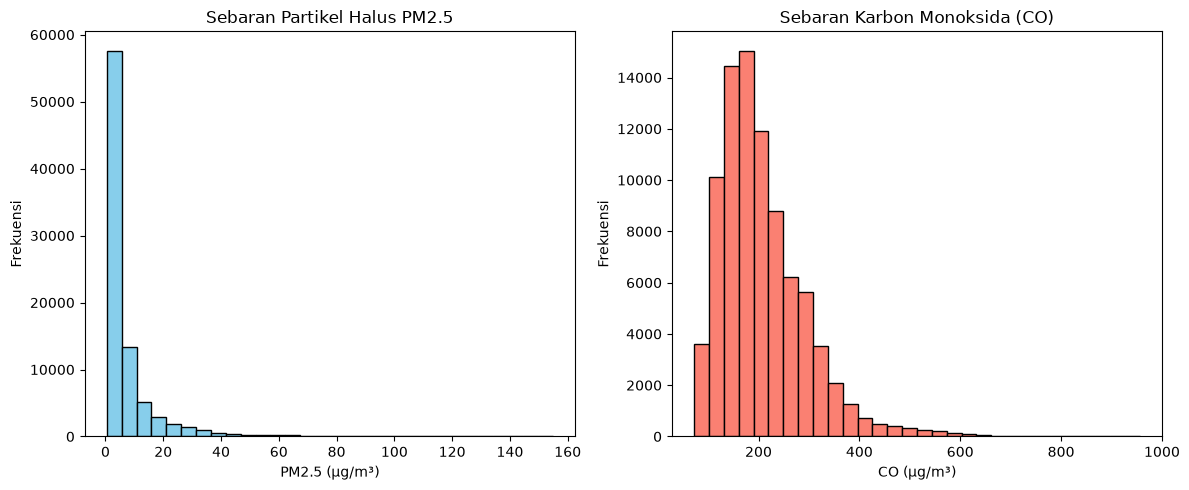

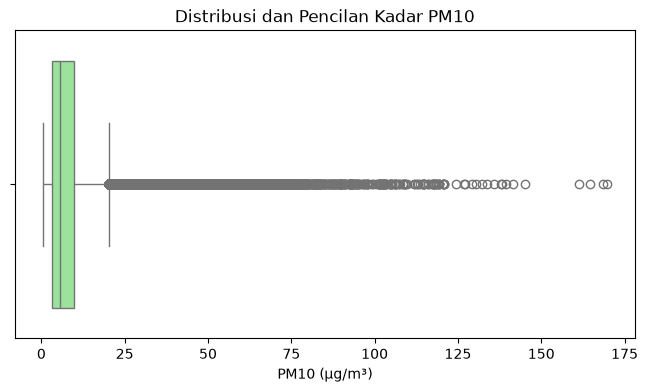

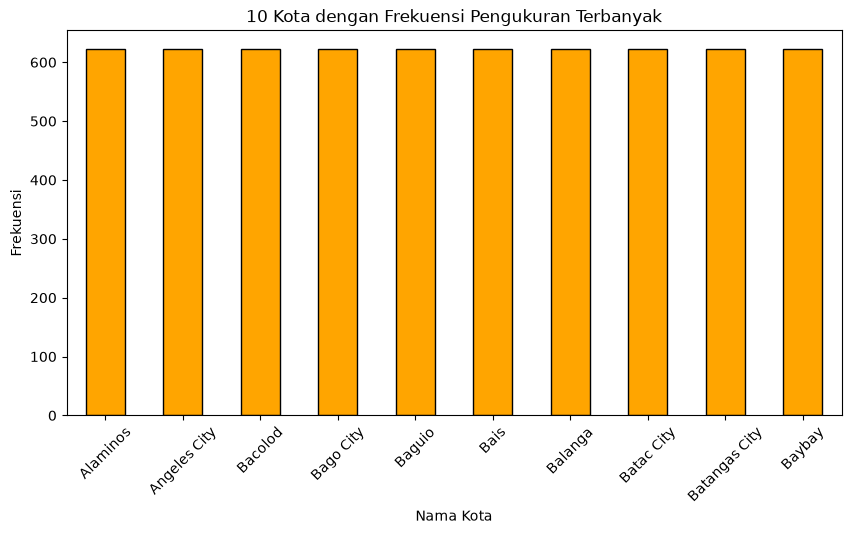

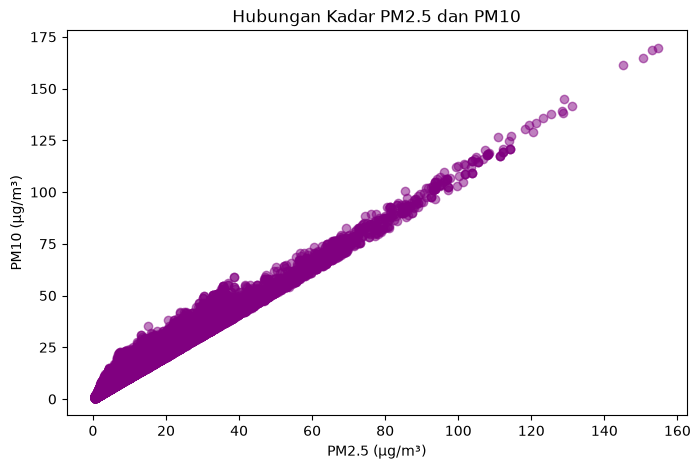

In [6]:

# 1. Histogram (2 Kolom Numerik: PM2.5 dan CO)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(df["components.pm2_5"], bins=30, color='skyblue', edgecolor='black')
ax[0].set_title("Sebaran Partikel Halus PM2.5")
ax[0].set_xlabel("PM2.5 (µg/m³)")
ax[0].set_ylabel("Frekuensi")

ax[1].hist(df["components.co"], bins=30, color='salmon', edgecolor='black')
ax[1].set_title("Sebaran Karbon Monoksida (CO)")
ax[1].set_xlabel("CO (µg/m³)")
ax[1].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# 2. Boxplot (1 Kolom Numerik: PM10)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["components.pm10"], color='lightgreen')
plt.title("Distribusi dan Pencilan Kadar PM10")
plt.xlabel("PM10 (µg/m³)")
plt.show()

# 3. Diagram Batang (Kategorik: city_name)
plt.figure(figsize=(10, 5))
df["city_name"].value_counts().head(10).plot(kind='bar', color='orange', edgecolor='black')
plt.title("10 Kota dengan Frekuensi Pengukuran Terbanyak")
plt.xlabel("Nama Kota")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

# 4. Scatter Plot (Korelasi PM2.5 dan PM10)
plt.figure(figsize=(8, 5))
plt.scatter(df["components.pm2_5"], df["components.pm10"], alpha=0.5, color='purple')
plt.title("Hubungan Kadar PM2.5 dan PM10")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("PM10 (µg/m³)")
plt.show()

### Interpretasi Grafik:
1. **Histogram PM2.5 & CO**: 

    Sebaran konsentrasi PM2.5 dan CO menunjukkan bentuk yang miring ke kanan (*positive skewness*). Artinya, frekuensi pengukuran lebih banyak berkumpul di kadar polutan rendah hingga sedang, namun terdapat ekor panjang ke kanan yang menandakan terjadinya lonjakan polusi pada momen-momen tertentu.
2. **Boxplot PM10**: 

    Terdapat sangat banyak titik pencilan (*outliers*) di atas garis kumis atas (*upper whisker*). Hal ini mengonfirmasi bahwa anomali lonjakan debu partikel kasar (hingga mencapai maksimal 169.63 µg/m³) ekstrem sangat sering terjadi dan jauh meninggalkan batas kuartil atasnya (Q3 di angka 9.93 µg/m³).
3. **Diagram Batang Kota**: 

    Frekuensi pengambilan data pada kota teratas sangat seragam (rata). Ini mengindikasikan bahwa sistem sensor kualitas udara di sebagian besar wilayah kota di Filipina bekerja dengan konsistensi waktu yang sangat stabil.
4. **Scatter Plot PM2.5 vs PM10**: 

    Terlihat pola garis lurus diagonal yang sangat rapat. Ini menunjukkan adanya korelasi linear positif yang sangat kuat antara debu halus (PM2.5) dan debu kasar (PM10). Jika partikel PM2.5 di udara meningkat, maka PM10 sudah pasti akan ikut meroket.

## 9. Kesimpulan
**Jawaban Pertanyaan Analisis:**
1. **Perbandingan Pemusatan dan Penyebaran:** 

    Karbon Monoksida (CO) memiliki kadar pemusatan (rata-rata 208,07 µg/m³) dan tingkat penyebaran (jangkauan 883,93 µg/m³) paling tinggi dibandingkan polutan lain. Ketiga polutan (CO, PM2.5, O3) memiliki sebaran data yang miring ke kanan (*positive skewness*), karena nilai rata-ratanya lebih besar dari nilai mediannya.
2. **Anomali PM10:** 

    Ya, berdasarkan grafik *boxplot*, terdapat sangat banyak titik anomali (pencilan/*outliers*) yang berada jauh di atas batas kumis atas (nilai maksimal mencapai 169,63 µg/m³ sedangkan Q3 hanya 9,93 µg/m³). Hal ini membuktikan seringnya terjadi lonjakan polusi debu kasar secara ekstrem yang patut diwaspadai.
3. **Hubungan PM2.5 dan PM10:** 

    Terdapat pola hubungan linear positif yang sangat kuat (korelasi nyaris sempurna di angka 0.98) antara debu halus (PM2.5) dan debu kasar (PM10). Kenaikan pada salah satu ukuran partikel tersebut akan selalu diikuti oleh kenaikan partikel lainnya secara proporsional.
4. **Distribusi Letak Sensor:** 

    Distribusi tidak didominasi oleh segelintir kota. Sebaliknya, sensor pengukuran didistribusikan dengan tingkat keteraturan yang luar biasa, di mana 99 kota (dari total 139 kota) menyumbang jumlah baris data yang sama persis (yaitu 623 pengukuran untuk setiap kota).

**Temuan Paling Menarik:**
* **Kualitas Data Sempurna:** 
    
    Dataset ini memiliki rekam data yang luar biasa bersih (0 *missing values*, 0 *duplicates*) dan konsistensi pengambilan sampel waktu yang sangat adil di 99 kota Filipina.
* **Kerentanan Lonjakan Polusi:** 

    Mayoritas polutan udara memiliki distribusi miring ke kanan, menandakan kualitas udara rata-rata sebenarnya normal, namun sangat rentan terhadap insiden polusi ekstrem (seperti kebakaran atau kemacetan parah).
* **Korelasi Partikulat:** 

    Pergerakan kadar debu halus (PM2.5) dan debu kasar (PM10) di udara ternyata sangat beriringan layaknya satu kesatuan.


## 10. Referensi dan Catatan Penggunaan AI


### Sumber Dataset & Referensi Belajar
* **Dataset**: [Philippine Cities Air Quality Index Data 2026](https://www.kaggle.com/datasets/bwandowando/philippine-cities-air-quality-index-data-2026)
* **Referensi Belajar**:
    * Dokumentasi resmi dari [Pandas](https://pandas.pydata.org/docs/)

### Catatan Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
| :--- | :--- | :--- |
| GeminiAI | Menanyakan arti fig di bagian kode histogran `fig, ax = plt.subplots(1, 2, figsize=(12, 5))` | fig itu gunanya untuk membuat bingkai gambar (figure) dengan ukuran 12x5 inci. |
| GeminiAI | Menanyakan arti bins pada kode histogram | bins itu untuk menentukan jumlah kelompok rentang nilai (interval) |